In [28]:
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization,AveragePooling2D
import matplotlib.pyplot as plt

In [29]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                      shear_range=0.2, 
                                        zoom_range=0.2,
                                        horizontal_flip=True)
x_train = train_datagen.flow_from_directory(
        'dataset/train',
        target_size = (32,32),
        color_mode="grayscale",
        batch_size=4,
        class_mode='binary'
        )

Found 30 images belonging to 2 classes.


In [30]:
test_datagen = ImageDataGenerator(rescale=1./255)
x_test = test_datagen.flow_from_directory(
        'dataset/test',
        target_size=(32,32),
        batch_size=4,
        color_mode="grayscale",
        class_mode='binary')

Found 30 images belonging to 2 classes.


In [31]:
def model_cnn(input_shape=(32,32,1), num_classes=1):   
    model = Sequential()
    model.add(Conv2D(32, kernel_size = (3,3), activation='tanh', input_shape = (32,32,1)))
    model.add(BatchNormalization())
    model.add(Conv2D(32, kernel_size = (3,3), activation='tanh'))
    model.add(BatchNormalization())
    model.add(Conv2D(32, kernel_size = (5,5), strides=2, padding='same', activation='tanh'))
    model.add(BatchNormalization())
    
    model.add(Conv2D(64, kernel_size = (3,3), activation='tanh'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, kernel_size = (3,3), activation='tanh'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, kernel_size = (5,5), strides=2, padding='same', activation='tanh'))
    model.add(BatchNormalization())

    model.add(Conv2D(128, kernel_size = 4, activation='tanh'))
    model.add(BatchNormalization())
    # To be able to merge into fully connected layer we have to flatten
    model.add(Flatten())
    # Lets add softmax activated neurons as much as number of classes
    model.add(Dense(1 ,activation = "sigmoid"))
    # Compile the model with loss and metrics
    model.compile(optimizer =  "adam" , loss = "binary_crossentropy", metrics=["accuracy"])
    
    return model

In [32]:
def LeNet5(input_shape=(32,32,1),num_classes=1):
    model = Sequential()
    model.add(Conv2D(4, kernel_size=(5, 5), strides=(1, 1), activation='tanh', input_shape=(32,32,1), padding="same"))
    model.add(AveragePooling2D(pool_size=(2, 2), strides=(1, 1)))
    model.add(Conv2D(8, kernel_size=(5, 5), strides=(1, 1), activation='tanh'))
    model.add(AveragePooling2D(pool_size=(2, 2), strides=(2, 2)))
    model.add(Conv2D(16, kernel_size=(5, 5), strides=(1, 1), activation='tanh'))
    model.add(Flatten())
    model.add(Dense(128, activation='tanh'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer =  "adam" , loss = "binary_crossentropy", metrics=["accuracy"])
    return model

In [33]:
model = []
model.append(model_cnn())
model.append(LeNet5())

In [34]:
models = []
for i in range(len(model)):
    r = model[i].fit(x=x_train,epochs = 40 ,validation_data = x_test)
    models.append(model[i])

Epoch 1/40
8/8 [==============================] - 2s 91ms/step - loss: 2.1589 - accuracy: 0.3333 - val_loss: 0.9768 - val_accuracy: 0.5000
Epoch 2/40
8/8 [==============================] - 0s 58ms/step - loss: 0.9272 - accuracy: 0.7000 - val_loss: 1.4251 - val_accuracy: 0.5000
Epoch 3/40
8/8 [==============================] - 0s 57ms/step - loss: 1.1341 - accuracy: 0.6667 - val_loss: 1.0787 - val_accuracy: 0.5000
Epoch 4/40
8/8 [==============================] - 0s 54ms/step - loss: 1.4933 - accuracy: 0.6333 - val_loss: 0.8173 - val_accuracy: 0.5000
Epoch 5/40
8/8 [==============================] - 0s 54ms/step - loss: 1.7782 - accuracy: 0.5667 - val_loss: 1.9833 - val_accuracy: 0.5000
Epoch 6/40
8/8 [==============================] - 0s 56ms/step - loss: 0.8623 - accuracy: 0.7667 - val_loss: 1.4043 - val_accuracy: 0.5000
Epoch 7/40
8/8 [==============================] - 0s 52ms/step - loss: 0.3520 - accuracy: 0.8667 - val_loss: 1.0159 - val_accuracy: 0.5000
Epoch 8/40
8/8 [===========

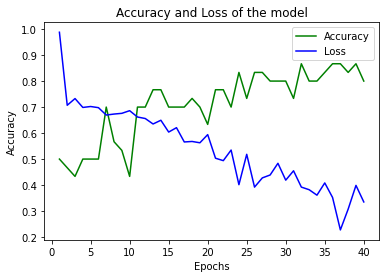

In [40]:
loss_train = r.history['accuracy']
loss = r.history['loss']
epochs = range(1,41)
plt.plot(epochs, loss_train, 'g', label='Accuracy')
plt.plot(epochs, loss, 'b', label='Loss')
plt.title('Accuracy and Loss of the model')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()